In [1]:
pip install pgmpy networkx matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 49.4 MB/s eta 0:00:00


In [2]:
import pprint
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import numpy as np
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# DiscreteBayesianNetwork if available; fallback to BayesianModel
try:
    from pgmpy.models import DiscreteBayesianNetwork as BNModel
    from pgmpy.sampling import BayesianModelSampling
    from pgmpy.estimators import MaximumLikelihoodEstimator
    MODEL_NAME = "DiscreteBayesianNetwork"
except Exception:
    from pgmpy.models import BayesianModel as BNModel
    from pgmpy.sampling import BayesianModelSampling
    from pgmpy.estimators import MaximumLikelihoodEstimator
    MODEL_NAME = "BayesianModel (fallback)"

print(f"Using model class: {MODEL_NAME}")


Using model class: DiscreteBayesianNetwork


In [3]:
# 1. Define the network structure (edges)
edges = [
    ("C", "W"),
    ("T", "W"),
    ("T", "I"),
    ("S", "I"),
    ("W", "J"),
    ("I", "J"),
]

model = BNModel(edges)

# 2. Define CPDs
cpd_C = TabularCPD("C", 3, [[0.2], [0.5], [0.3]], state_names={"C": ["Low", "Medium", "High"]})
cpd_T = TabularCPD("T", 2, [[0.4], [0.6]], state_names={"T": ["Weak", "Strong"]})
cpd_S = TabularCPD("S", 2, [[0.5], [0.5]], state_names={"S": ["Weak", "Strong"]})

# Written Test (W | C, T)
written_values = [
    [0.8, 0.6, 0.3, 0.4, 0.2, 0.1],
    [0.2, 0.4, 0.7, 0.6, 0.8, 0.9],
]
written_cpd = TabularCPD(
    variable="W", variable_card=2, values=written_values,
    evidence=["C", "T"], evidence_card=[3, 2],
    state_names={"W": ["Fail", "Pass"], "C": ["Low", "Medium", "High"], "T": ["Weak", "Strong"]}
)

# Interview (I | T, S)
interview_values = [
    [0.7, 0.4, 0.3, 0.1],
    [0.3, 0.6, 0.7, 0.9],
]
interview_cpd = TabularCPD(
    variable="I", variable_card=2, values=interview_values,
    evidence=["T", "S"], evidence_card=[2, 2],
    state_names={"I": ["Fail", "Pass"], "T": ["Weak", "Strong"], "S": ["Weak", "Strong"]}
)

# Job Offer (J | W, I)
offer_values = [
    [0.99, 0.8, 0.6, 0.1],
    [0.01, 0.2, 0.4, 0.9],
]
offer_cpd = TabularCPD(
    variable="J", variable_card=2, values=offer_values,
    evidence=["W", "I"], evidence_card=[2, 2],
    state_names={"J": ["No", "Yes"], "W": ["Fail", "Pass"], "I": ["Fail", "Pass"]}
)


Model and CPDs added and verified.


/tmp/ipython-input-42987933.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


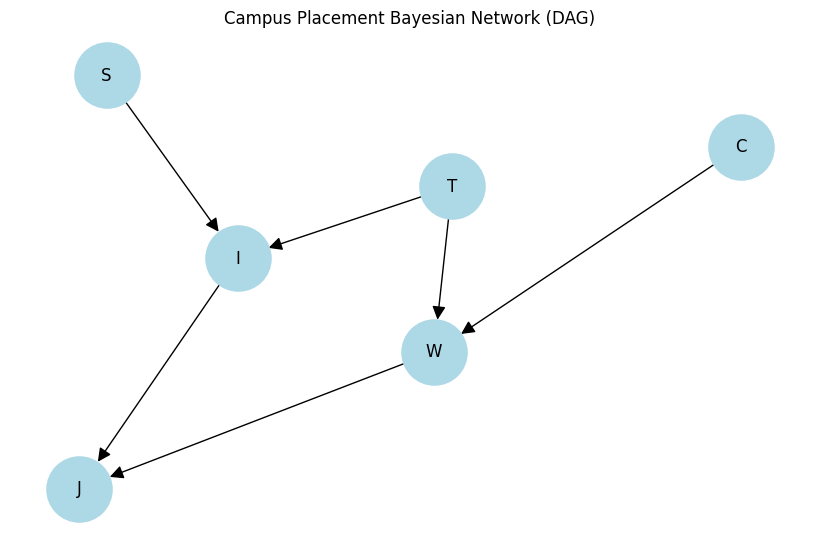

In [4]:
# 3. Add CPDs to the model
model.add_cpds(cpd_C, cpd_T, cpd_S, written_cpd, interview_cpd, offer_cpd)

# 4. Check model correctness
assert model.check_model(), "Model failed check_model() - CPDs inconsistent or missing."
print("Model and CPDs added and verified.")

# 5. Visualize DAG
def draw_dag(m):
    G = nx.DiGraph()
    G.add_edges_from(m.edges())
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=2200, node_color="lightblue", arrowsize=20)
    plt.title("Campus Placement Bayesian Network (DAG)")
    plt.tight_layout()
    plt.show()

draw_dag(model)


In [5]:
# 6. Inference setup
infer = VariableElimination(model)
pp = pprint.PrettyPrinter(indent=2)

# Query 1: Baseline P(J)
q1 = infer.query(variables=["J"])
print("\n1) Baseline P(J):")
pp.pprint(q1)

# Query 2: P(J | C='High', T='Strong')
q2 = infer.query(variables=["J"], evidence={"C": "High", "T": "Strong"})
print("\n2) P(J | C='High', T='Strong'):")
pp.pprint(q2)

# Query 3: P(T | J='Yes')
q3 = infer.query(variables=["T"], evidence={"J": "Yes"})
print("\n3) P(T | J='Yes'):")
pp.pprint(q3)

# Explaining-away
q4a = infer.query(variables=["W"], evidence={"J": "Yes"})
print("\n4a) P(W='Pass' | J='Yes'):")
pp.pprint(q4a)

q4b = infer.query(variables=["W"], evidence={"J": "Yes", "I": "Pass"})
print("\n4b) P(W='Pass' | J='Yes', I='Pass'):")
pp.pprint(q4b)

p_w_pass_given_j = float(q4a.values[q4a.state_names["W"].index("Pass")])
p_w_pass_given_j_i = float(q4b.values[q4b.state_names["W"].index("Pass")])

print("\nExplaining-away analysis:")
print(f"P(W=Pass | J=Yes) = {p_w_pass_given_j:.4f}")
print(f"P(W=Pass | J=Yes, I=Pass) = {p_w_pass_given_j_i:.4f}")
print(
    "When we add evidence that Interview=Pass, the probability that Written=Pass changes "
    "(often decreases here). This is because W and I are independent causes of J but become "
    "dependent once J is observed (v-structure: W -> J <- I) — knowledge that I=Pass can "
    "explain the Job=Yes, reducing the need to attribute the job to W=Pass (or vice versa)."
)



1) Baseline P(J):
<DiscreteFactor representing phi(J:2) at 0x782a2146afc0>

2) P(J | C='High', T='Strong'):
<DiscreteFactor representing phi(J:2) at 0x782903608a70>

3) P(T | J='Yes'):
<DiscreteFactor representing phi(T:2) at 0x782907667c50>

4a) P(W='Pass' | J='Yes'):
<DiscreteFactor representing phi(W:2) at 0x782a0a7af8f0>

4b) P(W='Pass' | J='Yes', I='Pass'):
<DiscreteFactor representing phi(W:2) at 0x782907732cf0>

Explaining-away analysis:
P(W=Pass | J=Yes) = 0.9070
P(W=Pass | J=Yes, I=Pass) = 0.8908
When we add evidence that Interview=Pass, the probability that Written=Pass changes (often decreases here). This is because W and I are independent causes of J but become dependent once J is observed (v-structure: W -> J <- I) — knowledge that I=Pass can explain the Job=Yes, reducing the need to attribute the job to W=Pass (or vice versa).


In [6]:
# 7. Generate 20,000 samples
sampler = BayesianModelSampling(model)
np.random.seed(42)
samples = sampler.forward_sample(size=20000, seed=42)

print("\nFirst 5 generated samples:")
print(samples.head())

# 8. Learn parameters using MLE
learned_model = BNModel(edges)
learned_model.fit(samples, estimator=MaximumLikelihoodEstimator)

# Retrieve learned CPD for P(J | W, I)
learned_offer_cpds = [cpd for cpd in learned_model.get_cpds() if cpd.variable == "J"]
if learned_offer_cpds:
    learned_offer_cpd = learned_offer_cpds[0]
    print("\nLearned CPD for P(J | W, I):")
    print(learned_offer_cpd)
else:
    print("Learned CPD for J not found in learned model CPDs.")


  0%|          | 0/6 [00:00<?, ?it/s]


First 5 generated samples:
        C     W       T     I     S    J
0  Medium  Fail  Strong  Pass  Weak   No
1    High  Pass    Weak  Pass  Weak  Yes
2    High  Pass    Weak  Fail  Weak  Yes
3  Medium  Pass  Strong  Pass  Weak  Yes
4     Low  Pass  Strong  Fail  Weak   No

Learned CPD for P(J | W, I):
+--------+----------------------+-----+---------------------+
| I      | I(Fail)              | ... | I(Pass)             |
+--------+----------------------+-----+---------------------+
| W      | W(Fail)              | ... | W(Pass)             |
+--------+----------------------+-----+---------------------+
| J(No)  | 0.9923541247484909   | ... | 0.09964454976303318 |
+--------+----------------------+-----+---------------------+
| J(Yes) | 0.007645875251509054 | ... | 0.9003554502369668  |
+--------+----------------------+-----+---------------------+


In [7]:
# Compare original and learned CPDs numerically
orig_vals = np.array(offer_cpd.values)
learned_vals = np.array(learned_offer_cpd.values)

print("\nOriginal P(J | W,I):")
print(orig_vals)
print("\nLearned P(J | W,I) (approx):")
print(learned_vals)

# Compute absolute differences
diff = np.abs(orig_vals - learned_vals)
print("\nAbsolute differences between original and learned CPDs:")
print(diff)

# Save samples to CSV
samples.to_csv("campus_placement_samples.csv", index=False)
print("\nGenerated samples saved to: campus_placement_samples.csv")



Original P(J | W,I):
[[[0.99 0.8 ]
  [0.6  0.1 ]]

 [[0.01 0.2 ]
  [0.4  0.9 ]]]

Learned P(J | W,I) (approx):
[[[0.99235412 0.59605027]
  [0.78848236 0.09964455]]

 [[0.00764588 0.40394973]
  [0.21151764 0.90035545]]]

Absolute differences between original and learned CPDs:
[[[0.00235412 0.20394973]
  [0.18848236 0.00035545]]

 [[0.00235412 0.20394973]
  [0.18848236 0.00035545]]]

Generated samples saved to: campus_placement_samples.csv
